In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, signal
from scipy.fft import rfft, rfftfreq

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]

In [9]:
class FourierSeries:
    def __init__(self, function, period, num_harmonics):
        self.function = function
        self.T = period
        self.N = num_harmonics
        self.omega = 2 * np.pi / self.T  # w = 2*pi/T

        # Списки для хранения коэффициентов
        self.a0 = 0
        self.a_n = []
        self.b_n = []

    def calculate_coefficients(self):
        """Численное интегрирование коэффициентов по формулам из методички"""
        t_start = -self.T / 2
        t_end = self.T / 2

        # 1. Расчет a0
        result_a0, error = integrate.quad(self.function, t_start, t_end)
        self.a0 = (2 / self.T) * result_a0

        self.a_n = []
        self.b_n = []

        # 2. Расчет an и bn для каждой гармоники n
        for n in range(1, self.N + 1):
            integrand_a = lambda t: self.function(t) * np.cos(n * self.omega * t)
            integrand_b = lambda t: self.function(t) * np.sin(n * self.omega * t)

            res_a, _ = integrate.quad(integrand_a, t_start, t_end)
            res_b, _ = integrate.quad(integrand_b, t_start, t_end)

            self.a_n.append((2 / self.T) * res_a)
            self.b_n.append((2 / self.T) * res_b)

    def reconstruct(self, t_values):
        """Восстановление функции из ряда Фурье: x*(t) = a0/2 + sum(...)"""
        result_signal = np.full_like(t_values, self.a0 / 2)

        for n in range(1, self.N + 1):
            idx = n - 1
            term = (self.a_n[idx] * np.cos(n * self.omega * t_values) +
                    self.b_n[idx] * np.sin(n * self.omega * t_values))
            result_signal += term
            
        return result_signal

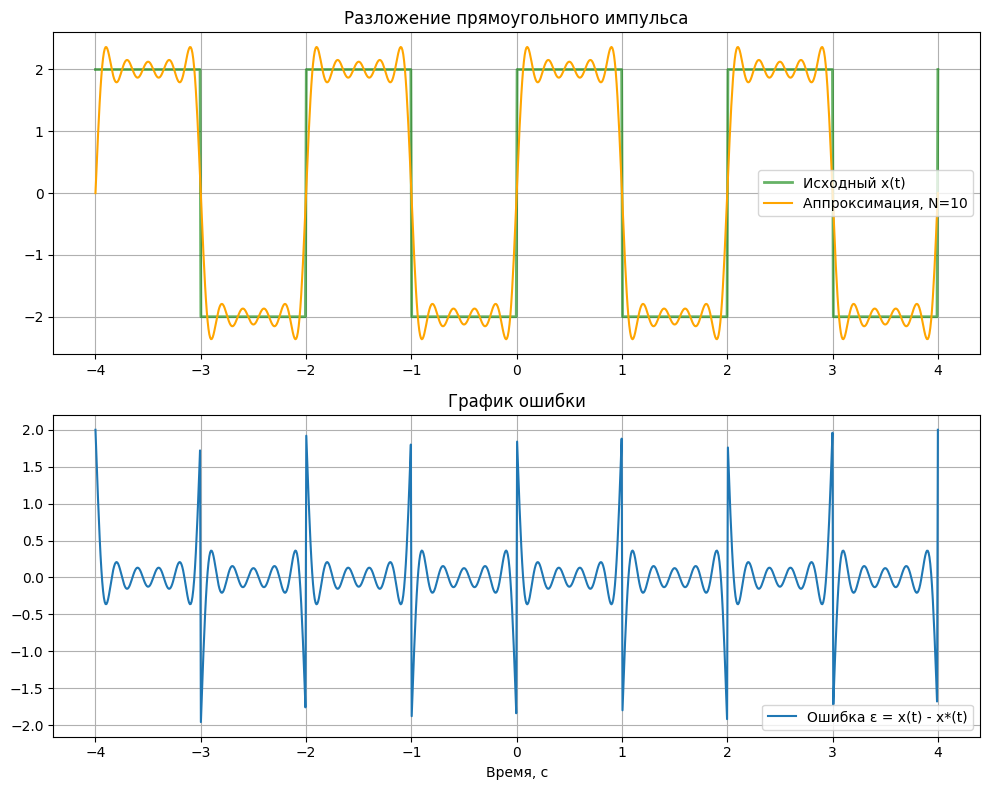

In [ ]:
# Параметры меандра
AMPLITUDE = 2.0
PERIOD = 2.0
N_HARMONICS = 10

def rect_pulse(t):
    return AMPLITUDE * signal.square(2 * np.pi * t / PERIOD)

# Выполняем разложение
fs = FourierSeries(rect_pulse, PERIOD, N_HARMONICS)
fs.calculate_coefficients()

t_values = np.linspace(-4, 4, 1000)
x_true = rect_pulse(t_values)
x_approx = fs.reconstruct(t_values)
error = x_true - x_approx

# Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t_values, x_true, label='Исходный x(t)', color='green', alpha=0.6, lw=2)
ax1.plot(t_values, x_approx, label=f'Аппроксимация, N={N_HARMONICS}', color='orange')
ax1.set_title('Разложение прямоугольного импульса')
ax1.grid(True); ax1.legend()

ax2.plot(t_values, error, label='Ошибка ε = x(t) - x*(t)', color='tab:blue')
ax2.set_title('График ошибки')
ax2.set_xlabel('Время, с'); ax2.grid(True); ax2.legend()
plt.tight_layout()
plt.show()

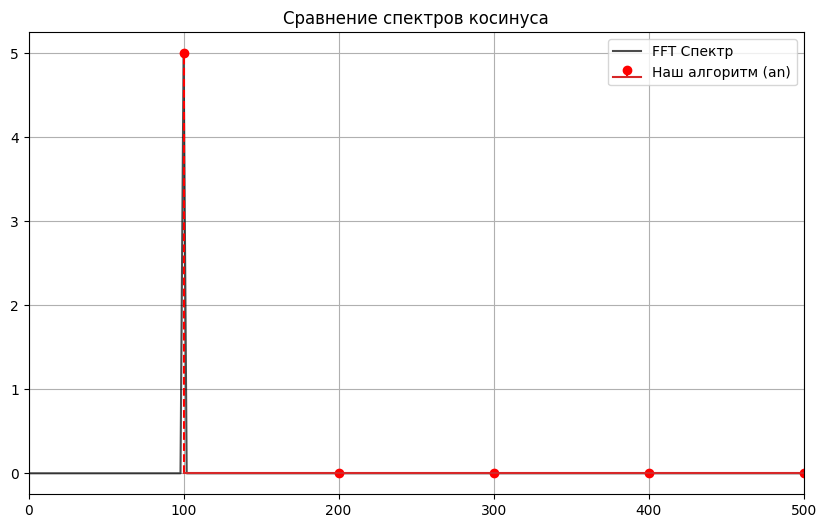

In [20]:
A_cos = 5.0
f_cos = 100.0
T_cos = 1.0 / f_cos

def cos_func(t):
    return A_cos * np.cos(2 * np.pi * f_cos * t)

# FFT расчет
fs_rate = 10000
t_fft = np.linspace(0, 0.5, int(0.5 * fs_rate), endpoint=False)
yf = rfft(cos_func(t_fft))
xf = rfftfreq(len(t_fft), 1/fs_rate)
spectrum_fft = 2.0 / len(t_fft) * np.abs(np.asarray(yf))

# Расчет через класс
fs_class = FourierSeries(cos_func, T_cos, 5)
fs_class.calculate_coefficients()

plt.figure()
plt.plot(xf, spectrum_fft, 'k', label='FFT Спектр', alpha=0.7)
plt.stem([f_cos*n for n in range(1, 6)], [abs(x) for x in fs_class.a_n], 
         linefmt='--r', markerfmt='ro', label='Наш алгоритм (an)')
plt.xlim(0, 500); plt.title('Сравнение спектров косинуса'); plt.grid(True); plt.legend()
plt.show()

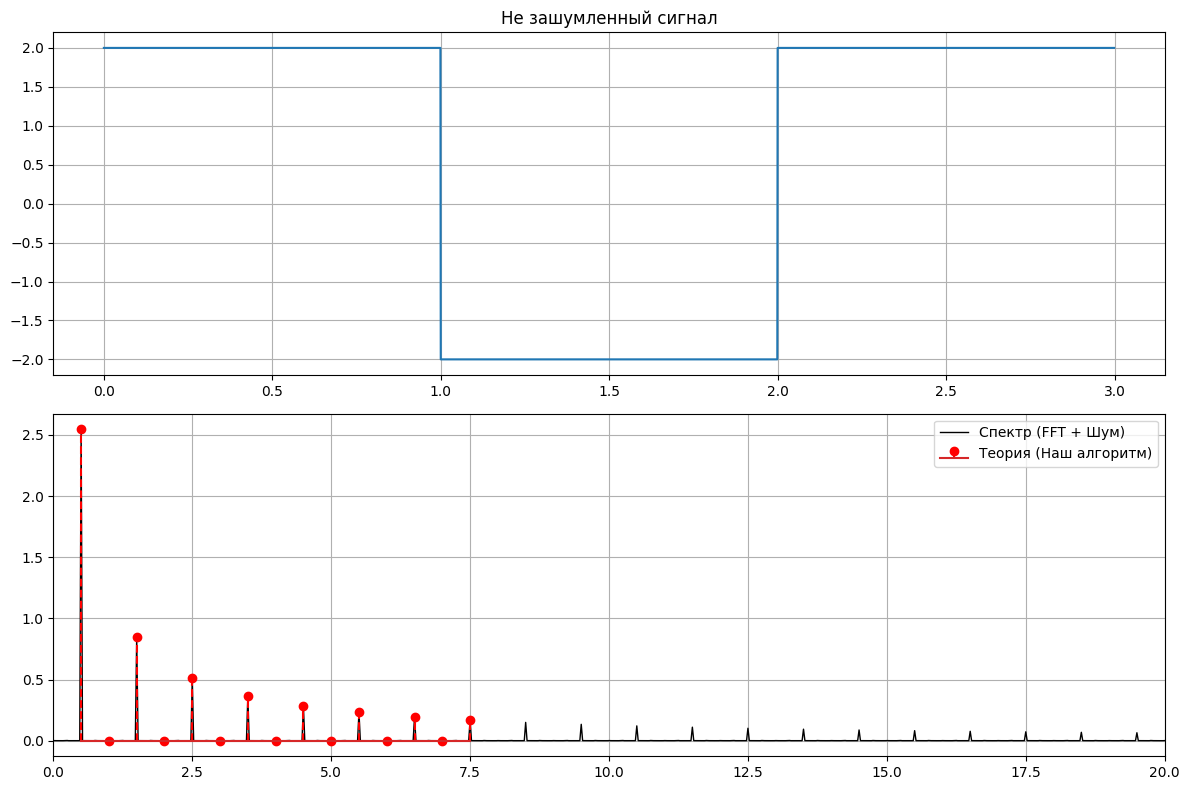

In [22]:
A_rect = 2.0
T_rect = 2.0
f_base = 1.0 / T_rect

def rect_func_final(t):
    return A_rect * signal.square(2 * np.pi * t / T_rect)

# Генерация зашумленного сигнала
fs_final = 1000
t_final = np.linspace(0, 40, int(40 * fs_final), endpoint=False)
x_noisy = rect_func_final(t_final)

# FFT
yf_final = rfft(x_noisy)
xf_final = rfftfreq(len(t_final), 1/fs_final)
spectrum_final = 2.0 / len(t_final) * np.abs(np.asarray(yf_final))

# Наш расчет (идеальный)
fs_final_class = FourierSeries(rect_func_final, T_rect, 15)
fs_final_class.calculate_coefficients()
our_amps = [np.sqrt(an**2 + bn**2) for an, bn in zip(fs_final_class.a_n, fs_final_class.b_n)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(t_final[:3000], x_noisy[:3000]); ax1.set_title('Не зашумленный сигнал'); ax1.grid(True)
ax2.plot(xf_final, spectrum_final, 'k', lw=1, label='Спектр (FFT + Шум)')
ax2.stem([f_base*n for n in range(1, 16)], our_amps, linefmt='--r', markerfmt='ro', label='Теория (Наш алгоритм)')
ax2.set_xlim(0, 20); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

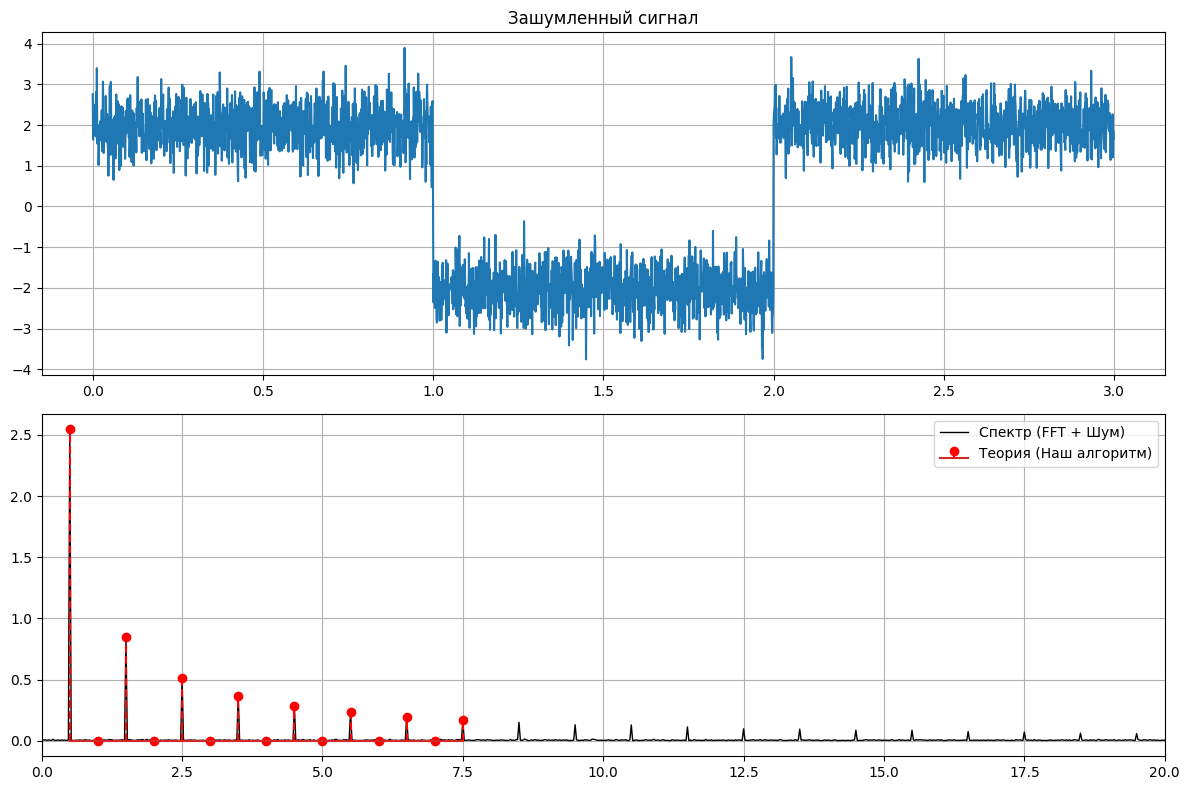

In [21]:
A_rect = 2.0
T_rect = 2.0
f_base = 1.0 / T_rect

def rect_func_final(t):
    return A_rect * signal.square(2 * np.pi * t / T_rect)

# Генерация зашумленного сигнала
fs_final = 1000
t_final = np.linspace(0, 40, int(40 * fs_final), endpoint=False)
x_noisy = rect_func_final(t_final) + np.random.normal(0, 0.5, size=len(t_final))

# FFT
yf_final = rfft(x_noisy)
xf_final = rfftfreq(len(t_final), 1/fs_final)
spectrum_final = 2.0 / len(t_final) * np.abs(np.asarray(yf_final))

# Наш расчет (идеальный)
fs_final_class = FourierSeries(rect_func_final, T_rect, 15)
fs_final_class.calculate_coefficients()
our_amps = [np.sqrt(an**2 + bn**2) for an, bn in zip(fs_final_class.a_n, fs_final_class.b_n)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(t_final[:3000], x_noisy[:3000]); ax1.set_title('Зашумленный сигнал'); ax1.grid(True)
ax2.plot(xf_final, spectrum_final, 'k', lw=1, label='Спектр (FFT + Шум)')
ax2.stem([f_base*n for n in range(1, 16)], our_amps, linefmt='--r', markerfmt='ro', label='Теория (Наш алгоритм)')
ax2.set_xlim(0, 20); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()